<a href="https://colab.research.google.com/github/FadilSadBoy20/BigData26_A_2411532013_Fadil-Insanus-Siddik/blob/main/Praktikum%203/BD_P03_2411532013_Fadil_Insanus_Siddik.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Praktikum**

K-1. Menyiapkan Lingkungan dan Memindahkan Perkakas dari Praktikum 1

In [1]:
import sys, time, os, json, sqlite3, gc
import pandas as pd, numpy as np, psutil

for nama in ["pandas", "numpy", "pyarrow", "requests", "sklearn", "sqlalchemy"]:
    try:
        mod = __import__(nama)
        print(f"{nama:11s}: {mod.__version__}")
    except ImportError:
        print(f"{nama:11s}: BELUM TERPASANG")

from google.colab import drive
drive.mount("/content/drive")

DIR_MENTAH = "/content/lapisan_mentah"
DIR_KURASI = "/content/lapisan_terkurasi"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum3"
for d in (DIR_MENTAH, DIR_KURASI, DIR_SIMPAN):
    os.makedirs(d, exist_ok=True)

# --- Dipakai kembali dari Praktikum 1 / K-3 ---
proses = psutil.Process(os.getpid())
catatan = []

def rss_mb():
    return proses.memory_info().rss / 1024**2

def ukur(label, fungsi):
    m0, t0 = rss_mb(), time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter() - t0
    catatan.append({"langkah": label, "detik": round(detik, 2),
                    "delta_rss_mb": round(rss_mb() - m0, 1)})
    print(f"[{label}] {detik:.2f} s")
    return hasil

# --- Baru di Praktikum 3: catatan asal-usul data (lineage) ---
lineage = []

def catat_sumber(nama, asal, jumlah_baris, keterangan=""):
    lineage.append({
        "sumber": nama, "asal": asal,
        "diambil_pada": pd.Timestamp.now("UTC").isoformat(),
        "jumlah_baris": jumlah_baris, "keterangan": keterangan,
    })
    print(f"[lineage] {nama}: {jumlah_baris:,} baris")

pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 23.0.1
requests   : 2.32.4
sklearn    : 1.6.1
sqlalchemy : 2.0.54
Mounted at /content/drive


K-2. Akuisisi 1 - Unduhan Berkala yang Tahan Gagal

In [2]:
import requests, shutil, os, time
import pandas as pd

# Hapus file zona yang biner/korup dari percobaan sebelumnya
if 'DIR_MENTAH' in locals():
    file_zona_bermasalah = os.path.join(DIR_MENTAH, "taxi_zone_lookup.csv")
    if os.path.exists(file_zona_bermasalah):
        os.remove(file_zona_bermasalah)
        print(f"Berkas korup lama dihapus: {file_zona_bermasalah}")

def unduh_aman(url, tujuan, percobaan=3, jeda_awal=2):
    """Unduh dengan retry + penulisan atomik. Melewati unduhan bila file sudah ada."""
    if os.path.exists(tujuan) and os.path.getsize(tujuan) > 0:
        print("cache ditemukan:", os.path.basename(tujuan))
        return tujuan

    sementara = tujuan + ".part"
    for i in range(percobaan):
        try:
            with requests.get(url, stream=True, timeout=60) as r:
                r.raise_for_status()
                with open(sementara, "wb") as f:
                    for chunk in r.iter_content(chunk_size=8192):
                        if chunk:
                            f.write(chunk)

            if os.path.getsize(sementara) == 0:
                raise IOError("berkas kosong")

            os.replace(sementara, tujuan) # atomik
            return tujuan
        except Exception as e:
            jeda = jeda_awal * (2 ** i) # exponential backoff
            print(f"percobaan {i+1} gagal ({e}); menunggu {jeda}s")
            time.sleep(jeda)

    raise RuntimeError(f"gagal mengunduh setelah {percobaan} percobaan: {url}")

# Definisi URL dan Path Tujuan
URL_TRIP = ("https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet")
URL_ZONA = ("https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv")
PATH_TRIP = os.path.join(DIR_MENTAH, "yellow_tripdata_2023-01.parquet")
PATH_ZONA = os.path.join(DIR_MENTAH, "taxi_zone_lookup.csv")

# Eksekusi Unduhan dengan pencatatan waktu
ukur("unduh trip", lambda: unduh_aman(URL_TRIP, PATH_TRIP))
ukur("unduh zona", lambda: unduh_aman(URL_ZONA, PATH_ZONA))

# Cek ukuran file yang berhasil diunduh
for pth in (PATH_TRIP, PATH_ZONA):
    print(os.path.basename(pth), "->", round(os.path.getsize(pth)/1024**2, 2), "MB")

# Membaca Data ke dalam Pandas DataFrame
KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime", "passenger_count",
         "trip_distance", "PULocationID", "DOLocationID", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]

trip = ukur("baca trip", lambda: pd.read_parquet(PATH_TRIP, columns=KOLOM))
zona = pd.read_csv(PATH_ZONA)

# Mencatat asal-usul (lineage)
catat_sumber("trip", URL_TRIP, len(trip), "Parquet bulanan TLC")
catat_sumber("zona", URL_ZONA, len(zona), "tabel dimensi 265 zona")

zona.head()

[unduh trip] 0.75 s
[unduh zona] 0.02 s
yellow_tripdata_2023-01.parquet -> 45.46 MB
taxi_zone_lookup.csv -> 0.01 MB
[baca trip] 0.61 s
[lineage] trip: 3,066,766 baris
[lineage] zona: 265 baris


,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


In [3]:
# ============================================================
# LATIHAN 1 - Kecepatan Unduh dan Cache
# ============================================================

import time
import os

def unduh_aman(url, tujuan, percobaan=3, jeda_awal=2):
    """Unduh dengan retry + cache + laporan kecepatan."""

    # Cek cache
    if os.path.exists(tujuan) and os.path.getsize(tujuan) > 0:
        ukuran_mb = os.path.getsize(tujuan) / 1024**2
        print(f"cache ditemukan: {os.path.basename(tujuan)}")
        print(f"ukuran file: {ukuran_mb:.2f} MB")
        print("kecepatan unduh: 0 MB/s (tidak ada proses unduh)")
        return tujuan

    sementara = tujuan + ".part"

    for i in range(percobaan):
        try:
            t0 = time.perf_counter()

            with requests.get(url, stream=True, timeout=60) as r:
                r.raise_for_status()

                with open(sementara, "wb") as f:
                    for chunk in r.iter_content(chunk_size=8192):
                        if chunk:
                            f.write(chunk)

            waktu = time.perf_counter() - t0
            ukuran_mb = os.path.getsize(sementara) / 1024**2
            kecepatan = ukuran_mb / waktu

            if ukuran_mb == 0:
                raise IOError("berkas kosong")

            os.replace(sementara, tujuan)

            print(f"unduh berhasil: {os.path.basename(tujuan)}")
            print(f"ukuran file: {ukuran_mb:.2f} MB")
            print(f"kecepatan unduh: {kecepatan:.2f} MB/s")

            return tujuan

        except Exception as e:
            jeda = jeda_awal * (2 ** i)
            print(
                f"percobaan {i+1} gagal ({e}); "
                f"menunggu {jeda}s"
            )
            time.sleep(jeda)

    raise RuntimeError(
        f"gagal mengunduh setelah {percobaan} percobaan: {url}"
    )

In [4]:
# Hapus file sementara hanya untuk membuktikan unduhan pertama
if os.path.exists(PATH_ZONA):
    os.remove(PATH_ZONA)

print("=== Panggilan pertama ===")
unduh_aman(URL_ZONA, PATH_ZONA)

print("\n=== Panggilan kedua ===")
unduh_aman(URL_ZONA, PATH_ZONA)

=== Panggilan pertama ===
unduh berhasil: taxi_zone_lookup.csv
ukuran file: 0.01 MB
kecepatan unduh: 0.48 MB/s

=== Panggilan kedua ===
cache ditemukan: taxi_zone_lookup.csv
ukuran file: 0.01 MB
kecepatan unduh: 0 MB/s (tidak ada proses unduh)


'/content/lapisan_mentah/taxi_zone_lookup.csv'

K-3. Akuisisi 2 - Memanggil API JSON

In [5]:
API_CUACA = "https://archive-api.open-meteo.com/v1/archive"

def ambil_cuaca(mulai, selesai, lat=40.7128, lon=-74.0060, percobaan=3):
    parameter = {
        "latitude": lat, "longitude": lon,
        "start_date": mulai, "end_date": selesai,
        "hourly": "temperature_2m,precipitation",
        "timezone": "America/New_York",
    }
    for i in range(percobaan):
        r = requests.get(API_CUACA, params=parameter, timeout=60)
        if r.status_code == 200:
            data = r.json()
            if "hourly" not in data:  # validasi struktur
                raise ValueError("kunci 'hourly' tidak ada pada respons")
            return pd.DataFrame(data["hourly"])
        if r.status_code in (429, 500, 502, 503):  # layak dicoba ulang
            time.sleep(2 ** i)
            continue
        r.raise_for_status()  # galat lain: hentikan
    raise RuntimeError("API cuaca tidak merespons dengan benar")

cuaca = ukur("ambil cuaca", lambda: ambil_cuaca("2023-01-01", "2023-01-31"))
cuaca["time"] = pd.to_datetime(cuaca["time"])
cuaca = cuaca.rename(columns={"time": "jam_mulai",
                              "temperature_2m": "suhu_c",
                              "precipitation": "hujan_mm"})
catat_sumber("cuaca", API_CUACA, len(cuaca), "Open-Meteo hourly archive")
cuaca.head()

[ambil cuaca] 0.84 s
[lineage] cuaca: 744 baris


,jam_mulai,suhu_c,hujan_mm
0,2023-01-01 00:00:00,10.9,1.0
1,2023-01-01 01:00:00,10.6,1.0
2,2023-01-01 02:00:00,10.6,0.1
3,2023-01-01 03:00:00,10.5,0.0
4,2023-01-01 04:00:00,9.8,0.0


In [30]:
# ============================================================
# LATIHAN 5 - Membuktikan validate="many_to_one"
# ============================================================

# Salin tabel zona agar tabel asli tidak berubah
zona_uji = zona.copy()

# Gandakan satu baris
zona_uji = pd.concat(
    [zona_uji, zona_uji.iloc[[0]]],
    ignore_index=True
)

print("Jumlah baris zona asli :", len(zona))
print("Jumlah baris zona uji  :", len(zona_uji))

print(
    "\nLocationID yang digandakan:",
    zona_uji.loc[
        zona_uji["LocationID"].duplicated(keep=False),
        "LocationID"
    ].unique()
)

# Coba join dengan validasi many_to_one
try:
    hasil_uji = bersih.merge(
        zona_uji[
            ["LocationID", "Borough", "Zone"]
        ],
        left_on="PULocationID",
        right_on="LocationID",
        how="left",
        validate="many_to_one"
    )

    print("Join berhasil.")

except Exception as e:
    print("\n=== ERROR YANG DIHARAPKAN ===")
    print(type(e).__name__)
    print(e)

# Pastikan tabel asli tetap sama
print("\nJumlah baris zona asli setelah pengujian:", len(zona))
print("LocationID unik pada zona asli:", zona["LocationID"].is_unique)

Jumlah baris zona asli : 265
Jumlah baris zona uji  : 266

LocationID yang digandakan: [1]

=== ERROR YANG DIHARAPKAN ===
MergeError
Merge keys are not unique in right dataset; not a many-to-one merge

Jumlah baris zona asli setelah pengujian: 265
LocationID unik pada zona asli: True


K-4. Jalur Cadangan bila Internet Diblokir

Karena langkah K-3 berhasil, saya lanjutkan ke langkah k-5

K-5. Akuisisi 3 - Basis Data SQLite dengan Pemuatan Bertahap

In [6]:
from sqlalchemy import create_engine

PATH_DB = os.path.join(DIR_MENTAH, "operasional.db")
engine = create_engine(f"sqlite:///{PATH_DB}")

tarif_referensi = pd.DataFrame({
    "payment_type": [1, 2, 3, 4, 5, 6],
    "nama_pembayaran": ["Kartu kredit", "Tunai", "Gratis",
                        "Sengketa", "Tidak diketahui", "Perjalanan batal"],
    "kena_biaya_admin": [1, 0, 0, 0, 0, 0],
})
tarif_referensi.to_sql("tarif_referensi", engine, if_exists="replace", index=False)

# tabel transaksi tiruan untuk latihan pembacaan bertahap
trip.head(300_000).to_sql(
    "trip_operasional", engine, if_exists="replace",
    index=False, chunksize=50_000)

print("Tabel dibuat:", pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table'", engine)["name"].tolist())

SQL = """
SELECT payment_type, COUNT(*) AS jumlah, AVG(total_amount) AS rata_total
FROM trip_operasional
WHERE total_amount > 0
GROUP BY payment_type
ORDER BY jumlah DESC
"""
ringkas_db = pd.read_sql(SQL, engine)
print(ringkas_db)

# Pembacaan bertahap: agregasi tanpa memuat seluruh tabel ke memori
total_baris = 0
for bagian in pd.read_sql("SELECT trip_distance FROM trip_operasional",
                          engine, chunksize=50_000):
    total_baris += len(bagian)
print("dibaca bertahap:", f"{total_baris:,}", "baris")

tarif_referensi = pd.read_sql("SELECT * FROM tarif_referensi", engine)
catat_sumber("tarif_referensi", PATH_DB, len(tarif_referensi),
             "tabel dimensi dari basis data operasional")

Tabel dibuat: ['tarif_referensi', 'trip_operasional']
   payment_type  jumlah  rata_total
0             1  226967   31.339172
1             2   66504   25.218836
2             4    2082   26.611114
3             3    1553   22.089691
dibaca bertahap: 300,000 baris
[lineage] tarif_referensi: 6 baris


K-6. Profiling Kualitas Data pada Enam Dimensi

In [7]:
trip["durasi_menit"] = (
    (trip["tpep_dropoff_datetime"] - trip["tpep_pickup_datetime"])
    .dt.total_seconds() / 60)

def profil_kolom(df):
    baris = []
    for kol in df.columns:
        s = df[kol]
        baris.append({
            "kolom": kol, "tipe": str(s.dtype),
            "persen_hilang": round(100 * s.isna().mean(), 3),
            "nilai_unik": s.nunique(dropna=True),
            "contoh": s.dropna().iloc[0] if s.notna().any() else None,
        })
    return pd.DataFrame(baris)

profil = profil_kolom(trip)
profil

AWAL, AKHIR = pd.Timestamp("2023-01-01"), pd.Timestamp("2023-02-01")
zona_sah = set(zona["LocationID"])
aturan = {
    "kelengkapan: passenger_count ada": trip["passenger_count"].notna(),
    "keunikan: baris tidak duplikat": ~trip.duplicated(),
    "validitas: jarak 0-100 mil": trip["trip_distance"].between(0.01, 100),
    "validitas: total_amount > 0": trip["total_amount"] > 0,
    "validitas: PULocationID dikenal": trip["PULocationID"].isin(zona_sah),
    "konsistensi: durasi 1-180 menit": trip["durasi_menit"].between(1, 180),
    "konsistensi: total >= fare": trip["total_amount"] >= trip["fare_amount"],
    "ketepatan waktu: dalam Jan 2023": trip["tpep_pickup_datetime"].between(AWAL, AKHIR),
}
laporan = pd.DataFrame([
    {"aturan": nama, "lulus": int(mask.sum()), "gagal": int((~mask).sum()),
     "persen_gagal": round(100 * (~mask).mean(), 3)}
    for nama, mask in aturan.items()
]).sort_values("persen_gagal", ascending=False)
laporan

,aturan,lulus,gagal,persen_gagal
0,kelengkapan: passenger_count ada,2995023,71743,2.339
2,validitas: jarak 0-100 mil,3020816,45950,1.498
5,konsistensi: durasi 1-180 menit,3030383,36383,1.186
3,validitas: total_amount > 0,3040994,25772,0.840
6,konsistensi: total >= fare,3041743,25023,0.816
7,ketepatan waktu: dalam Jan 2023,3066718,48,0.002
1,keunikan: baris tidak duplikat,3066766,0,0.000
4,validitas: PULocationID dikenal,3066766,0,0.000


In [26]:
# ============================================================
# LATIHAN 2 - Aturan Kualitas Tambahan
# ============================================================

aturan_tambahan = {
    # Validitas: tip tidak boleh negatif
    "validitas: tip_amount >= 0":
        trip["tip_amount"] >= 0,

    # Konsistensi: total harus mencakup fare + tip
    "konsistensi: total >= fare + tip":
        trip["total_amount"] >= (
            trip["fare_amount"] + trip["tip_amount"]
        ),
}

laporan_tambahan = pd.DataFrame([
    {
        "aturan": nama,
        "lulus": int(mask.sum()),
        "gagal": int((~mask).sum()),
        "persen_gagal": round(
            100 * (~mask).mean(), 3
        )
    }
    for nama, mask in aturan_tambahan.items()
])

print("=== Aturan Tambahan ===")
print(laporan_tambahan.to_string(index=False))

=== Aturan Tambahan ===
                          aturan   lulus  gagal  persen_gagal
      validitas: tip_amount >= 0 3066540    225         0.007
konsistensi: total >= fare + tip 3041605  25160         0.820


K-7. Nilai Hilang dan Duplikat

In [8]:
KOL = "passenger_count"
asli = trip[KOL]
print("persen hilang:", round(100 * asli.isna().mean(), 3))

trip["jam"] = trip["tpep_pickup_datetime"].dt.hour
strategi = {
    "1_dibuang": asli.dropna(),
    "2_isi_median": asli.fillna(asli.median()),
    "3_isi_modus": asli.fillna(asli.mode().iloc[0]),
    "4_median_perjam": asli.fillna(trip.groupby("jam")[KOL].transform("median")),
}
banding = pd.DataFrame([
    {"strategi": nama, "n": len(s), "mean": round(s.mean(), 4),
     "median": s.median(), "std": round(s.std(), 4)}
    for nama, s in strategi.items()
])
banding

# Strategi yang dipilih modul ini: tandai + isi per kelompok (lihat G.4)
trip[KOL + "_hilang"] = trip[KOL].isna().astype("int8")
trip[KOL] = trip[KOL].fillna(trip.groupby("jam")[KOL].transform("median"))
trip[KOL] = trip[KOL].fillna(trip[KOL].median())  # jaring pengaman

#tampilkan perbandingan strategi pengisian
print("=== Perbandingan Strategi Pengisian passenger_count ===")
print(banding.to_string(index=False))

# Perubahan simpangan baku dibanding data asli
std_asli = asli.dropna().std()

banding["perubahan_std"] = banding["std"] - std_asli
banding["perubahan_std_abs"] = banding["perubahan_std"].abs()

print("\nSimpangan baku data asli:", round(std_asli, 4))
print("\nPerubahan simpangan baku:")
print(
    banding[
        ["strategi", "std", "perubahan_std"]
    ].to_string(index=False)
)

terbesar = banding.loc[
    banding["perubahan_std_abs"].idxmax()
]

print(
    f"\nPerubahan simpangan baku terbesar: "
    f"{terbesar['strategi']} "
    f"({terbesar['perubahan_std']:.4f})"
)

# Duplikat: periksa dua tingkat
dup_penuh = trip.duplicated().sum()
KUNCI = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "PULocationID", "DOLocationID", "total_amount"]
dup_kunci = trip.duplicated(subset=KUNCI).sum()
print(f"duplikat penuh: {dup_penuh:,} | duplikat pada kunci: {dup_kunci:,}")

sebelum = len(trip)
trip = trip.drop_duplicates(subset=KUNCI, keep="first").reset_index(drop=True)
print(f"{sebelum:,} -> {len(trip):,} baris")

persen hilang: 2.339
=== Perbandingan Strategi Pengisian passenger_count ===
       strategi       n   mean  median    std
      1_dibuang 2995023 1.3625     1.0 0.8961
   2_isi_median 3066766 1.3541     1.0 0.8873
    3_isi_modus 3066766 1.3541     1.0 0.8873
4_median_perjam 3066766 1.3541     1.0 0.8873

Simpangan baku data asli: 0.8961

Perubahan simpangan baku:
       strategi    std  perubahan_std
      1_dibuang 0.8961       -0.00002
   2_isi_median 0.8873       -0.00882
    3_isi_modus 0.8873       -0.00882
4_median_perjam 0.8873       -0.00882

Perubahan simpangan baku terbesar: 2_isi_median (-0.0088)
duplikat penuh: 0 | duplikat pada kunci: 1
3,066,766 -> 3,066,765 baris


K-8. Outlier, Join dengan Tabel Referensi, dan Penggabungan Berbasis Waktu

In [9]:
def batas_iqr(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

def ringkas_outlier(df, kolom):
    hasil = []
    for kol in kolom:
        s = df[kol].dropna()
        lo, hi = batas_iqr(s)
        z = (s - s.mean()) / s.std()
        hasil.append({
            "kolom": kol, "batas_bawah": round(lo, 2), "batas_atas": round(hi, 2),
            "outlier_iqr": int(((s < lo) | (s > hi)).sum()),
            "outlier_z3": int((z.abs() > 3).sum()), "p99": round(s.quantile(0.99), 2),
        })
    return pd.DataFrame(hasil)

ringkas_outlier(trip, ["trip_distance", "durasi_menit", "total_amount"])

# Simpan dan tampilkan hasil outlier
hasil_outlier = ringkas_outlier(
    trip,
    ["trip_distance", "durasi_menit", "total_amount"]
)

print("=== Perbandingan Outlier IQR vs Z-score ===")
print(hasil_outlier.to_string(index=False))

# Khusus total_amount
out_total = hasil_outlier[
    hasil_outlier["kolom"] == "total_amount"
].iloc[0]

iqr_total = int(out_total["outlier_iqr"])
z_total = int(out_total["outlier_z3"])
selisih_outlier = abs(iqr_total - z_total)

print("\n=== total_amount ===")
print("Outlier IQR     :", iqr_total)
print("Outlier Z-score :", z_total)
print("Selisih          :", selisih_outlier)

# Tindakan berbeda untuk maksud berbeda (lihat G.5)
layak = (trip["trip_distance"].between(0.01, 100)
         & trip["durasi_menit"].between(1, 180)
         & (trip["total_amount"] > 0))
bersih = trip.loc[layak].copy()

# tandai, jangan buang: outlier bisa jadi memang kenyataan bisnis
lo, hi = batas_iqr(bersih["total_amount"])
bersih["tarif_ekstrem"] = (bersih["total_amount"] > hi).astype("int8")

# winsorizing hanya untuk kolom turunan yang akan dipakai model
batas_atas = bersih["trip_distance"].quantile(0.995)
bersih["trip_distance_capped"] = bersih["trip_distance"].clip(upper=batas_atas)

print(f"{len(trip):,} -> {len(bersih):,} baris "
      f"({100*(1-len(bersih)/len(trip)):.2f}% dibuang)")

# --- Join 1: tabel zona (dimensi) ---
print("kunci zona unik?", zona["LocationID"].is_unique)  # WAJIB diperiksa
n0 = len(bersih)
bersih = bersih.merge(
    zona[["LocationID", "Borough", "Zone"]]
    .rename(columns={"Borough": "borough_naik", "Zone": "zona_naik"}),
    left_on="PULocationID", right_on="LocationID",
    how="left", validate="many_to_one")
bersih = bersih.drop(columns="LocationID")
# gagal keras bila tidak 1:1
print(f"baris {n0:,} -> {len(bersih):,} (harus sama)")
print("zona tak dikenal:", bersih["zona_naik"].isna().sum())

# --- Join 2: tabel pembayaran dari basis data ---
bersih = bersih.merge(tarif_referensi[["payment_type", "nama_pembayaran"]],
                      on="payment_type", how="left", validate="many_to_one")

# --- Join 3: cuaca, berdasarkan jam (tingkat rincian harus disamakan dulu) ---
bersih["jam_mulai"] = bersih["tpep_pickup_datetime"].dt.floor("h")
n0 = len(bersih)
bersih = bersih.merge(cuaca, on="jam_mulai", how="left", validate="many_to_one")
print(f"baris {n0:,} -> {len(bersih):,}")
print("tanpa data cuaca:", bersih["suhu_c"].isna().sum())

=== Perbandingan Outlier IQR vs Z-score ===
        kolom  batas_bawah  batas_atas  outlier_iqr  outlier_z3    p99
trip_distance        -2.35        6.74       390244          67  20.06
 durasi_menit        -9.66       35.08       170615        3175  57.25
 total_amount        -4.55       48.65       371616       87248 101.94

=== total_amount ===
Outlier IQR     : 371616
Outlier Z-score : 87248
Selisih          : 284368
3,066,765 -> 2,986,910 baris (2.60% dibuang)
kunci zona unik? True
baris 2,986,910 -> 2,986,910 (harus sama)
zona tak dikenal: 37609
baris 2,986,910 -> 2,986,910
tanpa data cuaca: 37


In [10]:
# Tambahan K-8: analisis baris yang gagal memperoleh pasangan zona/cuaca

print("=== Analisis Zona Tidak Dikenal ===")

zona_hilang = bersih[bersih["zona_naik"].isna()].copy()

print("Jumlah zona tidak dikenal:", len(zona_hilang))

print("\nTop 10 PULocationID tanpa pasangan zona:")
print(
    zona_hilang["PULocationID"]
    .value_counts()
    .head(10)
)

print("\nDistribusi jam zona tidak dikenal:")
print(
    zona_hilang["tpep_pickup_datetime"]
    .dt.hour
    .value_counts()
    .sort_index()
)


print("\n=== Analisis Data Cuaca Tidak Ditemukan ===")

cuaca_hilang = bersih[bersih["suhu_c"].isna()].copy()

print("Jumlah tanpa data cuaca:", len(cuaca_hilang))

print("\nWaktu transaksi tanpa pasangan cuaca:")
print(
    cuaca_hilang["jam_mulai"]
    .value_counts()
    .sort_index()
)

print("\nTanggal transaksi tanpa pasangan cuaca:")
print(
    cuaca_hilang["tpep_pickup_datetime"]
    .dt.date
    .value_counts()
    .sort_index()
)

=== Analisis Zona Tidak Dikenal ===
Jumlah zona tidak dikenal: 37609

Top 10 PULocationID tanpa pasangan zona:
PULocationID
264    37609
Name: count, dtype: int64

Distribusi jam zona tidak dikenal:
tpep_pickup_datetime
0      985
1      598
2      367
3      299
4      158
5      186
6      496
7      921
8     1209
9     1728
10    1915
11    1962
12    1971
13    2296
14    2702
15    2267
16    2267
17    2453
18    2383
19    2470
20    2266
21    2288
22    1953
23    1469
Name: count, dtype: int64

=== Analisis Data Cuaca Tidak Ditemukan ===
Jumlah tanpa data cuaca: 37

Waktu transaksi tanpa pasangan cuaca:
jam_mulai
2022-10-25 00:00:00     2
2022-10-25 09:00:00     1
2022-12-31 14:00:00     2
2022-12-31 15:00:00     1
2022-12-31 22:00:00     3
2022-12-31 23:00:00    18
2023-02-01 00:00:00    10
Name: count, dtype: int64

Tanggal transaksi tanpa pasangan cuaca:
tpep_pickup_datetime
2022-10-25     3
2022-12-31    24
2023-02-01    10
Name: count, dtype: int64


In [11]:
# Tambahan: susut data kumulatif

n_awal = 3_066_766
n_setelah_duplikat = 3_066_765
n_akhir = len(bersih)

persen_tersisa = 100 * n_akhir / n_awal
persen_hilang = 100 - persen_tersisa

hilang_duplikat = n_awal - n_setelah_duplikat
hilang_filter = n_setelah_duplikat - n_akhir

print("=== Susut Data Kumulatif ===")
print(f"Data awal             : {n_awal:,}")
print(f"Setelah deduplikasi   : {n_setelah_duplikat:,}")
print(f"Setelah filtering     : {n_akhir:,}")
print(f"Data tersisa          : {persen_tersisa:.2f}%")
print(f"Data hilang           : {persen_hilang:.2f}%")

print("\nKontribusi kehilangan:")
print(
    f"- Deduplikasi : {hilang_duplikat:,} baris "
    f"({100 * hilang_duplikat / n_awal:.4f}%)"
)
print(
    f"- Filtering   : {hilang_filter:,} baris "
    f"({100 * hilang_filter / n_awal:.2f}%)"
)

=== Susut Data Kumulatif ===
Data awal             : 3,066,766
Setelah deduplikasi   : 3,066,765
Setelah filtering     : 2,986,910
Data tersisa          : 97.40%
Data hilang           : 2.60%

Kontribusi kehilangan:
- Deduplikasi : 1 baris (0.0000%)
- Filtering   : 79,855 baris (2.60%)


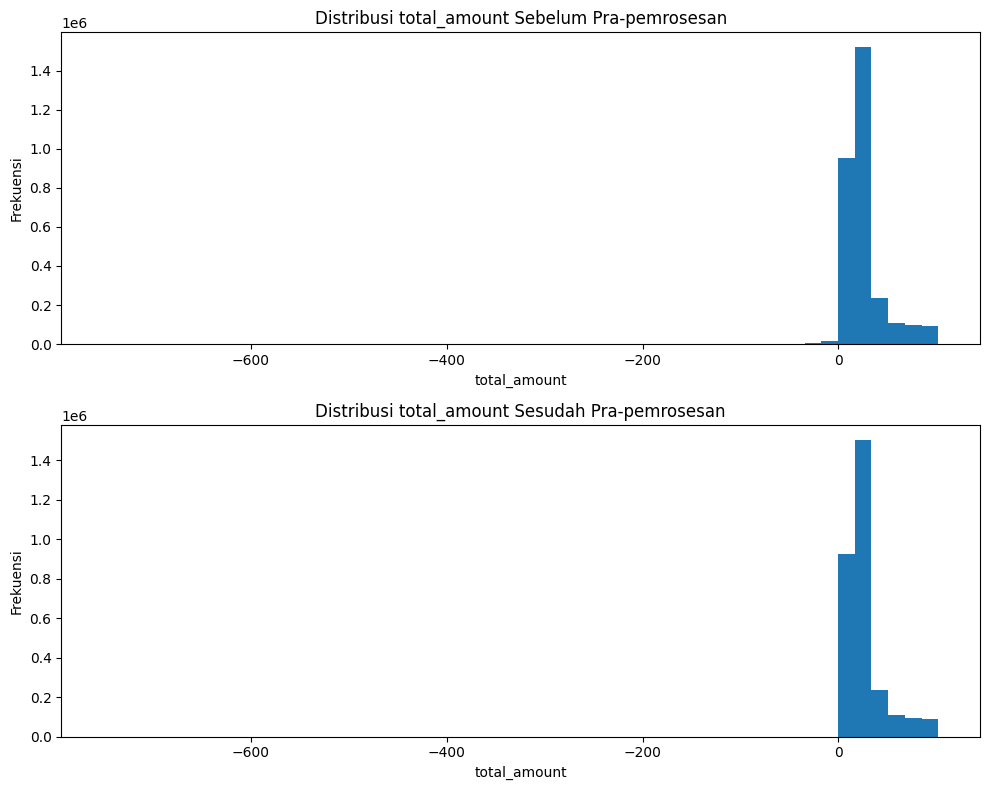

In [12]:
# Tambahan K-8/K-10: histogram total_amount
import matplotlib.pyplot as plt

# Ambil data total_amount mentah
data_awal = pd.read_parquet(
    PATH_TRIP,
    columns=["total_amount"]
)["total_amount"].dropna()

# Data setelah pra-pemrosesan
data_akhir = bersih["total_amount"].dropna()

# Gunakan batas sumbu-X yang sama
x_min = min(data_awal.min(), data_akhir.min())
x_max = max(data_awal.max(), data_akhir.max())

# Batasi ke persentil 99 agar bentuk distribusi lebih mudah terlihat
x_batas = data_awal.quantile(0.99)

bins = 50

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].hist(
    data_awal[data_awal <= x_batas],
    bins=bins,
    range=(x_min, x_batas)
)

axes[0].set_title("Distribusi total_amount Sebelum Pra-pemrosesan")
axes[0].set_xlabel("total_amount")
axes[0].set_ylabel("Frekuensi")

axes[1].hist(
    data_akhir[data_akhir <= x_batas],
    bins=bins,
    range=(x_min, x_batas)
)

axes[1].set_title("Distribusi total_amount Sesudah Pra-pemrosesan")
axes[1].set_xlabel("total_amount")
axes[1].set_ylabel("Frekuensi")

plt.tight_layout()
plt.show()

In [27]:
# ============================================================
# LATIHAN 3 - Join Lokasi Tujuan
# ============================================================

zona_tujuan = (
    zona[["LocationID", "Borough"]]
    .rename(columns={
        "LocationID": "DOLocationID",
        "Borough": "borough_turun"
    })
)

bersih_tujuan = bersih.merge(
    zona_tujuan,
    on="DOLocationID",
    how="left",
    validate="many_to_one"
)

print("Jumlah baris setelah join:")
print(len(bersih_tujuan))

print("\nTujuan tidak dikenal:")
print(bersih_tujuan["borough_turun"].isna().sum())

Jumlah baris setelah join:
2986910

Tujuan tidak dikenal:
9511


In [28]:
# Hitung jumlah perjalanan setiap pasangan borough
top10_pasangan = (
    bersih_tujuan
    .groupby(
        ["borough_naik", "borough_turun"],
        observed=True
    )
    .size()
    .reset_index(name="jumlah_perjalanan")
    .sort_values(
        "jumlah_perjalanan",
        ascending=False
    )
    .head(10)
)

print("=== 10 Pasangan Borough Asal-Tujuan Terbanyak ===")
display(top10_pasangan)

=== 10 Pasangan Borough Asal-Tujuan Terbanyak ===


,borough_naik,borough_turun,jumlah_perjalanan
22,Manhattan,Manhattan,2491566
29,Queens,Manhattan,155261
23,Manhattan,Queens,82354
20,Manhattan,Brooklyn,62986
30,Queens,Queens,59146
27,Queens,Brooklyn,42187
42,Unknown,Manhattan,18432
45,Unknown,Unknown,13562
19,Manhattan,Bronx,8865
8,Brooklyn,Brooklyn,7910


K-9. Rekayasa Fitur: Encoding dan Scaling Tanpa Kebocoran

In [13]:
bersih["hari_minggu"] = bersih["tpep_pickup_datetime"].dt.dayofweek
bersih["akhir_pekan"] = (bersih["hari_minggu"] >= 5).astype("int8")
bersih["kecepatan_mph"] = (bersih["trip_distance"] / (bersih["durasi_menit"] / 60)).round(2)
bersih["tarif_per_mil"] = (bersih["total_amount"] / bersih["trip_distance"]).round(3)
bersih["hujan"] = (bersih["hujan_mm"].fillna(0) > 0.1).astype("int8")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

FITUR_NUM = ["trip_distance_capped", "durasi_menit", "suhu_c"]
FITUR_KAT = ["nama_pembayaran", "borough_naik"]

contoh = bersih.dropna(subset=FITUR_NUM + FITUR_KAT).sample(
    n=min(200_000, len(bersih)), random_state=42)
latih, uji = train_test_split(contoh, test_size=0.2, random_state=42)

skala = StandardScaler().fit(latih[FITUR_NUM])  # fit HANYA di data latih
latih_num = skala.transform(latih[FITUR_NUM])
uji_num = skala.transform(uji[FITUR_NUM])       # transform saja, tanpa fit ulang
print("mean latih (harus ~0):", latih_num.mean(axis=0).round(3))
print("mean uji (tidak harus 0):", uji_num.mean(axis=0).round(3))

# Bergantung versi: parameter sparse_output ada sejak scikit-learn 1.2
enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
enc.fit(latih[FITUR_KAT])
latih_kat = enc.transform(latih[FITUR_KAT])
print("jumlah kolom hasil one-hot:", latih_kat.shape[1])
print("nama kolom:", enc.get_feature_names_out()[:6], "...")

mean latih (harus ~0): [-0.  0. -0.]
mean uji (tidak harus 0): [ 0.001  0.001 -0.009]
jumlah kolom hasil one-hot: 11
nama kolom: ['nama_pembayaran_Gratis' 'nama_pembayaran_Kartu kredit'
 'nama_pembayaran_Sengketa' 'nama_pembayaran_Tunai' 'borough_naik_Bronx'
 'borough_naik_Brooklyn'] ...


In [29]:
# ============================================================
# LATIHAN 4 - StandardScaler vs MinMaxScaler
# ============================================================

from sklearn.preprocessing import StandardScaler, MinMaxScaler

# StandardScaler
standard = StandardScaler().fit(
    latih[FITUR_NUM]
)

latih_standard = standard.transform(
    latih[FITUR_NUM]
)

# MinMaxScaler
minmax = MinMaxScaler().fit(
    latih[FITUR_NUM]
)

latih_minmax = minmax.transform(
    latih[FITUR_NUM]
)

print("=== Rentang StandardScaler ===")

for i, kolom in enumerate(FITUR_NUM):
    print(
        f"{kolom}: "
        f"min={latih_standard[:, i].min():.3f}, "
        f"max={latih_standard[:, i].max():.3f}"
    )

print("\n=== Rentang MinMaxScaler ===")

for i, kolom in enumerate(FITUR_NUM):
    print(
        f"{kolom}: "
        f"min={latih_minmax[:, i].min():.3f}, "
        f"max={latih_minmax[:, i].max():.3f}"
    )

=== Rentang StandardScaler ===
trip_distance_capped: min=-0.794, max=4.247
durasi_menit: min=-1.226, max=13.925
suhu_c: min=-2.288, max=3.347

=== Rentang MinMaxScaler ===
trip_distance_capped: min=0.000, max=1.000
durasi_menit: min=0.000, max=1.000
suhu_c: min=0.000, max=1.000


K-10. Membungkus Jadi Pipeline, Memvalidasi, dan Menyimpan Berpartisi

In [14]:
KONTRAK = {
    "tpep_pickup_datetime": "datetime64[ns]", "trip_distance": "float64",
    "durasi_menit": "float64", "total_amount": "float64",
    "borough_naik": "object", "nama_pembayaran": "object",
}

def validasi(df, kontrak=KONTRAK):
    masalah = []
    for kol, tipe in kontrak.items():
        if kol not in df.columns:
            masalah.append(f"kolom hilang: {kol}")
        elif not str(df[kol].dtype).startswith(tipe.split("[")[0]):
            masalah.append(f"tipe {kol}: {df[kol].dtype} != {tipe}")
    if df.empty:
        masalah.append("DataFrame kosong")
    if len(df) != len(df.drop_duplicates(subset=KUNCI)):
        masalah.append("masih ada duplikat pada kunci")
    if masalah:
        raise AssertionError("Validasi gagal:\n- " + "\n- ".join(masalah))
    print(f"Validasi lulus: {len(df):,} baris x {df.shape[1]} kolom")
    return df

validasi(bersih)

def pipeline(path_trip, path_zona, df_cuaca, df_tarif):
    """Satu fungsi, idempoten: input mentah -> DataFrame tervalidasi."""
    df = pd.read_parquet(path_trip, columns=KOLOM)
    z = pd.read_csv(path_zona)
    df["durasi_menit"] = ((df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"])
                          .dt.total_seconds() / 60)
    df["jam"] = df["tpep_pickup_datetime"].dt.hour
    df["passenger_count"] = df["passenger_count"].fillna(
        df.groupby("jam")["passenger_count"].transform("median"))
    df = df.drop_duplicates(subset=KUNCI)
    df = df[df["trip_distance"].between(0.01, 100)
            & df["durasi_menit"].between(1, 180)
            & (df["total_amount"] > 0)]
    df = (df.merge(z[["LocationID", "Borough"]]
                   .rename(columns={"Borough": "borough_naik"}),
                   left_on="PULocationID", right_on="LocationID",
                   how="left", validate="many_to_one")
          .drop(columns="LocationID")
          .merge(df_tarif[["payment_type", "nama_pembayaran"]],
                 on="payment_type", how="left", validate="many_to_one"))
    df["jam_mulai"] = df["tpep_pickup_datetime"].dt.floor("h")
    df = df.merge(df_cuaca, on="jam_mulai", how="left", validate="many_to_one")
    return validasi(df)

hasil = ukur("pipeline penuh", lambda: pipeline(PATH_TRIP, PATH_ZONA, cuaca, tarif_referensi))

OUT = os.path.join(DIR_KURASI, "trips_bersih")
hasil["tanggal"] = hasil["tpep_pickup_datetime"].dt.date.astype(str)
ukur("tulis parquet berpartisi", lambda: hasil.to_parquet(
    OUT, partition_cols=["borough_naik"], index=False))
print("partisi yang terbentuk:", sorted(os.listdir(OUT))[:5], "...")

# Bukti idempotensi: jalankan ulang, hasil harus identik
ulang = pipeline(PATH_TRIP, PATH_ZONA, cuaca, tarif_referensi)
print("idempoten?", len(ulang) == len(hasil))

# Artefak yang dikumpulkan
laporan.to_csv(f"{DIR_SIMPAN}/laporan_kualitas.csv", index=False)
pd.DataFrame(lineage).to_csv(f"{DIR_SIMPAN}/lineage.csv", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)
shutil.make_archive(f"{DIR_SIMPAN}/trips_bersih", "zip", OUT)

Validasi lulus: 2,986,910 baris x 26 kolom
Validasi lulus: 2,986,910 baris x 17 kolom
[pipeline penuh] 4.57 s
[tulis parquet berpartisi] 2.87 s
partisi yang terbentuk: ['borough_naik=Bronx', 'borough_naik=Brooklyn', 'borough_naik=EWR', 'borough_naik=Manhattan', 'borough_naik=Queens'] ...
Validasi lulus: 2,986,910 baris x 17 kolom
idempoten? True


'/content/drive/MyDrive/BigData/Praktikum3/trips_bersih.zip'

In [15]:
# Tambahan K-10: pengukuran waktu pembacaan dan join
import time

print("=== Pengukuran Waktu Pipeline ===")

# 1. Pembacaan data utama
t0 = time.perf_counter()

df_test = pd.read_parquet(PATH_TRIP, columns=KOLOM)
z_test = pd.read_csv(PATH_ZONA)

t_baca = time.perf_counter() - t0

print(f"Waktu pembacaan data : {t_baca:.4f} detik")


# Persiapan data
df_test["durasi_menit"] = (
    (df_test["tpep_dropoff_datetime"] -
     df_test["tpep_pickup_datetime"])
    .dt.total_seconds() / 60
)

df_test["jam"] = df_test["tpep_pickup_datetime"].dt.hour

df_test["passenger_count"] = df_test["passenger_count"].fillna(
    df_test.groupby("jam")["passenger_count"].transform("median")
)

df_test = df_test.drop_duplicates(subset=KUNCI)

df_test = df_test[
    df_test["trip_distance"].between(0.01, 100)
    & df_test["durasi_menit"].between(1, 180)
    & (df_test["total_amount"] > 0)
].copy()


# 2. Join zona
t0 = time.perf_counter()

df_test = df_test.merge(
    z_test[["LocationID", "Borough"]]
    .rename(columns={"Borough": "borough_naik"}),
    left_on="PULocationID",
    right_on="LocationID",
    how="left",
    validate="many_to_one"
).drop(columns="LocationID")

t_zona = time.perf_counter() - t0


# 3. Join pembayaran
t0 = time.perf_counter()

df_test = df_test.merge(
    tarif_referensi[["payment_type", "nama_pembayaran"]],
    on="payment_type",
    how="left",
    validate="many_to_one"
)

t_pembayaran = time.perf_counter() - t0


# 4. Join cuaca
df_test["jam_mulai"] = (
    df_test["tpep_pickup_datetime"].dt.floor("h")
)

t0 = time.perf_counter()

df_test = df_test.merge(
    cuaca,
    on="jam_mulai",
    how="left",
    validate="many_to_one"
)

t_cuaca = time.perf_counter() - t0


total_join = t_zona + t_pembayaran + t_cuaca

print(f"Waktu join zona       : {t_zona:.4f} detik")
print(f"Waktu join pembayaran : {t_pembayaran:.4f} detik")
print(f"Waktu join cuaca      : {t_cuaca:.4f} detik")
print(f"Total waktu join      : {total_join:.4f} detik")

print(
    f"Proporsi join terhadap waktu pembacaan: "
    f"{100 * total_join / t_baca:.2f}%"
)

print(
    f"Proporsi join terhadap (baca + join): "
    f"{100 * total_join / (t_baca + total_join):.2f}%"
)

=== Pengukuran Waktu Pipeline ===
Waktu pembacaan data : 0.4224 detik
Waktu join zona       : 0.3554 detik
Waktu join pembayaran : 0.2472 detik
Waktu join cuaca      : 0.4255 detik
Total waktu join      : 1.0281 detik
Proporsi join terhadap waktu pembacaan: 243.43%
Proporsi join terhadap (baca + join): 70.88%


In [16]:
# ============================================================
# STUDI KASUS - Pemeriksaan kolom
# ============================================================

kolom_dibutuhkan = [
    "borough_naik",
    "tpep_pickup_datetime",
    "total_amount",
    "tarif_per_mil",
    "kecepatan_mph",
    "suhu_c",
    "hujan"
]

print("Kolom yang tersedia:")
print(bersih.columns.tolist())

print("\nPemeriksaan kolom yang dibutuhkan:")
for kolom in kolom_dibutuhkan:
    print(f"{kolom:25} -> {kolom in bersih.columns}")

Kolom yang tersedia:
['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'tip_amount', 'total_amount', 'durasi_menit', 'jam', 'passenger_count_hilang', 'tarif_ekstrem', 'trip_distance_capped', 'borough_naik', 'zona_naik', 'nama_pembayaran', 'jam_mulai', 'suhu_c', 'hujan_mm', 'hari_minggu', 'akhir_pekan', 'kecepatan_mph', 'tarif_per_mil', 'hujan']

Pemeriksaan kolom yang dibutuhkan:
borough_naik              -> True
tpep_pickup_datetime      -> True
total_amount              -> True
tarif_per_mil             -> True
kecepatan_mph             -> True
suhu_c                    -> True
hujan                     -> True


In [17]:
# ============================================================
# STUDI KASUS - Membuat tabel analitik
# ============================================================

tabel_analitik = (
    bersih
    .assign(
        jam_mulai=bersih["tpep_pickup_datetime"].dt.floor("h")
    )
    .groupby(
        ["borough_naik", "jam_mulai"],
        observed=True
    )
    .agg(
        jumlah_perjalanan=("total_amount", "size"),
        rata_tarif_per_mil=("tarif_per_mil", "median"),
        rata_kecepatan=("kecepatan_mph", "median"),
        suhu_c=("suhu_c", "first"),
        hujan=("hujan", "max")
    )
    .reset_index()
)

# Ambang minimum 30 perjalanan
tabel_analitik = tabel_analitik[
    tabel_analitik["jumlah_perjalanan"] >= 30
].copy()

print("Ukuran tabel analitik:")
print(tabel_analitik.shape)

print("\nContoh tabel:")
display(tabel_analitik.head())

print("\nJumlah kelompok per borough:")
print(
    tabel_analitik["borough_naik"]
    .value_counts(dropna=False)
)

Ukuran tabel analitik:
(2094, 7)

Contoh tabel:


,borough_naik,jam_mulai,jumlah_perjalanan,rata_tarif_per_mil,rata_kecepatan,suhu_c,hujan
626,Brooklyn,2023-01-01 00:00:00,86,6.9385,14.550,10.9,1
627,Brooklyn,2023-01-01 01:00:00,220,6.9820,13.715,10.6,1
628,Brooklyn,2023-01-01 02:00:00,256,6.6215,15.445,10.6,0
629,Brooklyn,2023-01-01 03:00:00,175,6.6160,16.390,10.5,0
630,Brooklyn,2023-01-01 04:00:00,74,6.9120,14.635,9.8,0



Jumlah kelompok per borough:
borough_naik
Manhattan    744
Queens       679
Unknown      529
Brooklyn     142
Name: count, dtype: int64


In [18]:
# ============================================================
# STUDI KASUS - Perbandingan hujan vs tidak hujan
# ============================================================

perbandingan_hujan = (
    tabel_analitik
    .groupby(
        ["borough_naik", "hujan"],
        observed=True
    )["rata_tarif_per_mil"]
    .median()
    .unstack()
)

# Rapikan nama kolom
perbandingan_hujan = perbandingan_hujan.rename(
    columns={
        False: "tidak_hujan",
        True: "hujan"
    }
)

# Selisih dan perubahan persentase
perbandingan_hujan["selisih"] = (
    perbandingan_hujan["hujan"]
    - perbandingan_hujan["tidak_hujan"]
)

perbandingan_hujan["persen_perubahan"] = (
    perbandingan_hujan["selisih"]
    / perbandingan_hujan["tidak_hujan"]
    * 100
)

print("=== Perbandingan Tarif per Mil ===")
display(perbandingan_hujan)

=== Perbandingan Tarif per Mil ===


hujan,tidak_hujan,hujan,selisih,persen_perubahan
borough_naik,,,,
Brooklyn,6.9430,7.6550,0.7120,10.254933
Manhattan,10.5270,11.4000,0.8730,8.292961
Queens,5.4530,5.6365,0.1835,3.365120
Unknown,8.7255,9.8860,1.1605,13.300097


In [19]:
# Jumlah kelompok borough-jam untuk masing-masing kondisi
jumlah_kelompok = (
    tabel_analitik
    .groupby(
        ["borough_naik", "hujan"],
        observed=True
    )
    .size()
    .unstack(fill_value=0)
    .rename(
        columns={
            False: "jumlah_jam_tidak_hujan",
            True: "jumlah_jam_hujan"
        }
    )
)

print("=== Jumlah kelompok jam ===")
display(jumlah_kelompok)

=== Jumlah kelompok jam ===


hujan,jumlah_jam_tidak_hujan,jumlah_jam_hujan
borough_naik,,
Brooklyn,125,17
Manhattan,637,107
Queens,583,96
Unknown,450,79


In [20]:
# ============================================================
# STUDI KASUS - Menyimpan tabel analitik
# ============================================================

OUT_ANALITIK = os.path.join(
    DIR_KURASI,
    "tabel_analitik_pricing.parquet"
)

tabel_analitik.to_parquet(
    OUT_ANALITIK,
    index=False
)

print("Tabel analitik berhasil disimpan:")
print(OUT_ANALITIK)

Tabel analitik berhasil disimpan:
/content/lapisan_terkurasi/tabel_analitik_pricing.parquet


In [21]:
# Verifikasi file Parquet
cek_analitik = pd.read_parquet(OUT_ANALITIK)

print("Jumlah baris :", len(cek_analitik))
print("Jumlah kolom :", len(cek_analitik.columns))
print("\nKolom:")
print(cek_analitik.columns.tolist())

Jumlah baris : 2094
Jumlah kolom : 7

Kolom:
['borough_naik', 'jam_mulai', 'jumlah_perjalanan', 'rata_tarif_per_mil', 'rata_kecepatan', 'suhu_c', 'hujan']


In [22]:
# ============================================================
# STUDI KASUS - Membuat kamus_data.md
# ============================================================

kamus_data = """# Kamus Data - Tabel Analitik Pricing

## Tujuan

Tabel analitik ini digunakan untuk analisis awal hubungan antara kondisi
hujan dan tarif per mil pada tingkat borough per jam.

Satu baris merepresentasikan satu kombinasi borough dan jam.

## Sumber Data

Sumber utama:
- Data perjalanan: `yellow_tripdata_2023-01.parquet`
- Data zona: tabel zona yang digunakan pada pipeline K-10
- Data cuaca: tabel cuaca yang digunakan pada pipeline K-10
- Data pembayaran: tabel referensi pembayaran yang digunakan pada pipeline K-10

Data analitik dibentuk dari DataFrame `bersih` setelah tahap
pra-pemrosesan dan penggabungan data.

## Definisi Kolom

| Kolom | Definisi | Satuan | Cara Penghitungan |
|---|---|---|---|
| `borough_naik` | Borough lokasi penjemputan | kategori | Diambil dari hasil penggabungan `PULocationID` dengan tabel zona |
| `jam_mulai` | Awal jam transaksi | datetime | `tpep_pickup_datetime` dibulatkan ke awal jam menggunakan `.dt.floor("h")` |
| `jumlah_perjalanan` | Jumlah perjalanan dalam satu borough dan jam | perjalanan | Jumlah baris berdasarkan `total_amount` dengan agregasi `size` |
| `rata_tarif_per_mil` | Nilai tengah tarif per mil | mata uang/mil | Median `tarif_per_mil` dalam setiap kelompok borough-jam |
| `rata_kecepatan` | Nilai tengah kecepatan perjalanan | mph | Median `kecepatan_mph` dalam setiap kelompok borough-jam |
| `suhu_c` | Suhu pada waktu pengamatan | °C | Nilai pertama `suhu_c` pada setiap kelompok borough-jam |
| `hujan` | Penanda kondisi hujan | boolean | Nilai maksimum `hujan` pada setiap kelompok borough-jam |

## Catatan Penting

1. Kolom `rata_tarif_per_mil` menggunakan median, bukan mean, meskipun
   nama kolom menggunakan awalan `rata_`.
2. Kolom `rata_kecepatan` juga menggunakan median.
3. Kelompok dengan kurang dari 30 perjalanan dikeluarkan dari tabel
   analitik.
4. Data cuaca menggunakan satu sumber/titik pengamatan untuk mewakili
   kondisi kota sehingga tidak menangkap variasi cuaca lokal antarborough.
5. Perbandingan hujan dan tidak hujan menunjukkan hubungan/asosiasi,
   bukan hubungan sebab-akibat.
6. Hujan dapat terjadi bersamaan dengan faktor lain seperti jam sibuk,
   sehingga kenaikan tarif per mil tidak dapat langsung dianggap
   disebabkan oleh hujan.
7. Hasil hanya berlaku pada cakupan data yang digunakan dan tidak
   otomatis mewakili periode atau kondisi di luar data tersebut.

## Jejak Sumber

Alur utama:

`Data perjalanan mentah`
→ `Pra-pemrosesan`
→ `Join zona`
→ `Join pembayaran`
→ `Join cuaca`
→ `Data bersih`
→ `Agregasi borough per jam`
→ `Tabel analitik`

Setiap angka agregat dapat ditelusuri kembali melalui kombinasi
`borough_naik` dan `jam_mulai` ke baris-baris pada DataFrame `bersih`
yang menjadi sumber agregasinya.
"""

PATH_KAMUS = os.path.join(
    DIR_KURASI,
    "kamus_data.md"
)

with open(PATH_KAMUS, "w", encoding="utf-8") as f:
    f.write(kamus_data)

print("Kamus data berhasil dibuat:")
print(PATH_KAMUS)

Kamus data berhasil dibuat:
/content/lapisan_terkurasi/kamus_data.md


In [23]:
# ============================================================
# STUDI KASUS - Pemeriksaan traceability
# ============================================================

contoh = tabel_analitik.iloc[0]

borough = contoh["borough_naik"]
jam = contoh["jam_mulai"]

sumber = bersih[
    (bersih["borough_naik"] == borough) &
    (bersih["tpep_pickup_datetime"].dt.floor("h") == jam)
].copy()

print("=== Baris Analitik ===")
display(pd.DataFrame([contoh]))

print("\n=== Baris Sumber ===")
print("Jumlah baris sumber:", len(sumber))

display(
    sumber[
        [
            "tpep_pickup_datetime",
            "borough_naik",
            "tarif_per_mil",
            "kecepatan_mph",
            "suhu_c",
            "hujan"
        ]
    ].head(20)
)

print("\nMedian tarif per mil:",
      sumber["tarif_per_mil"].median())

print("Median kecepatan:",
      sumber["kecepatan_mph"].median())

=== Baris Analitik ===


,borough_naik,jam_mulai,jumlah_perjalanan,rata_tarif_per_mil,rata_kecepatan,suhu_c,hujan
626,Brooklyn,2023-01-01,86,6.9385,14.55,10.9,1



=== Baris Sumber ===
Jumlah baris sumber: 86


,tpep_pickup_datetime,borough_naik,tarif_per_mil,kecepatan_mph,suhu_c,hujan
14,2023-01-01 00:33:53,Brooklyn,8.217,11.52,10.9,1
279,2023-01-01 00:56:22,Brooklyn,7.194,13.41,10.9,1
409,2023-01-01 00:17:12,Brooklyn,8.741,9.57,10.9,1
410,2023-01-01 00:43:26,Brooklyn,7.663,13.06,10.9,1
430,2023-01-01 00:41:48,Brooklyn,9.507,16.71,10.9,1
570,2023-01-01 00:59:39,Brooklyn,8.779,11.54,10.9,1
962,2023-01-01 00:37:19,Brooklyn,13.379,9.82,10.9,1
1066,2023-01-01 00:33:42,Brooklyn,7.231,10.52,10.9,1
1067,2023-01-01 00:51:05,Brooklyn,6.828,11.80,10.9,1
1115,2023-01-01 00:45:24,Brooklyn,7.069,14.44,10.9,1



Median tarif per mil: 6.9384999999999994
Median kecepatan: 14.55


K-11. Pra-pemrosesan Setara dengan PySpark (Tambahan)

In [31]:
!pip install -q pyspark==3.5.1

from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder.appName("BD-P02").master("local[*]")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")

sdf = spark.read.parquet(PATH_TRIP).select(*KOLOM)
szona = spark.createDataFrame(zona[["LocationID", "Borough"]])

sbersih = (sdf
    .withColumn("durasi_menit",
                (F.unix_timestamp(F.col("tpep_dropoff_datetime"))
                 - F.unix_timestamp(F.col("tpep_pickup_datetime"))) / 60)
    .filter(F.col("trip_distance").between(0.01, 100))
    .filter(F.col("durasi_menit").between(1, 180))
    .filter(F.col("total_amount") > 0)
    .dropDuplicates(["tpep_pickup_datetime", "tpep_dropoff_datetime",
                     "PULocationID", "DOLocationID", "total_amount"])
    .join(F.broadcast(szona),  # tabel kecil: broadcast
          sdf.PULocationID == szona.LocationID, "left")
    .drop("LocationID"))

ukur("spark: hitung baris bersih", lambda: sbersih.count())
sbersih.groupBy("Borough").count().orderBy(F.desc("count")).show(10, False)

sbersih.write.mode("overwrite").partitionBy("Borough") \
    .parquet("/content/lapisan_terkurasi/trips_spark")

sbersih.explain()  # cari BroadcastHashJoin, bukan SortMergeJoin
spark.stop()

[spark: hitung baris bersih] 7.36 s
+-------------+-------+
|Borough      |count  |
+-------------+-------+
|Manhattan    |2659609|
|Queens       |270315 |
|Unknown      |37609  |
|Brooklyn     |15724  |
|Bronx        |3074   |
|NaN          |340    |
|Staten Island|211    |
|EWR          |28     |
+-------------+-------+

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [tpep_pickup_datetime#281, tpep_dropoff_datetime#282, passenger_count#525, trip_distance#527, PULocationID#287L, DOLocationID#288L, payment_type#529L, fare_amount#531, tip_amount#533, total_amount#296, durasi_menit#535, Borough#330]
   +- BroadcastHashJoin [PULocationID#287L], [LocationID#329L], LeftOuter, BuildRight, false
      :- HashAggregate(keys=[DOLocationID#288L, tpep_dropoff_datetime#282, PULocationID#287L, total_amount#296, tpep_pickup_datetime#281], functions=[first(passenger_count#283, false), first(trip_distance#284, false), first(payment_type#289L, false), first(fare_amount#290, false), 

In [32]:
# ============================================================
# LATIHAN 6 - Pipeline Inkremental
# ============================================================

def pipeline_inkremental(bulan):
    """
    Memproses bulan hanya jika hasil bulan tersebut
    belum tersedia di direktori keluaran.

    Format bulan:
    '2023-01'
    """

    # Direktori keluaran khusus latihan
    OUT_INKREMENTAL = os.path.join(
        DIR_KURASI,
        "pipeline_inkremental"
    )

    os.makedirs(
        OUT_INKREMENTAL,
        exist_ok=True
    )

    # Nama file keluaran
    nama_output = f"trips_bersih_{bulan}.parquet"
    path_output = os.path.join(
        OUT_INKREMENTAL,
        nama_output
    )

    # --------------------------------------------------------
    # 1. Cek apakah bulan sudah tersedia
    # --------------------------------------------------------

    if os.path.exists(path_output):
        print(
            f"[SKIP] {bulan} sudah tersedia: "
            f"{nama_output}"
        )
        return path_output

    # --------------------------------------------------------
    # 2. Tentukan file mentah
    # --------------------------------------------------------

    path_trip_bulan = os.path.join(
        DIR_MENTAH,
        f"yellow_tripdata_{bulan}.parquet"
    )

    if not os.path.exists(path_trip_bulan):
        raise FileNotFoundError(
            f"File bulan {bulan} tidak ditemukan:\n"
            f"{path_trip_bulan}"
        )

    # --------------------------------------------------------
    # 3. Proses menggunakan pipeline yang sudah dibuat
    # --------------------------------------------------------

    hasil_bulan = pipeline(
        path_trip_bulan,
        PATH_ZONA,
        cuaca,
        tarif_referensi
    )

    # --------------------------------------------------------
    # 4. Simpan hasil
    # --------------------------------------------------------

    hasil_bulan.to_parquet(
        path_output,
        index=False
    )

    print(
        f"[PROSES] {bulan} selesai -> "
        f"{nama_output}"
    )
    print(
        f"Jumlah baris: {len(hasil_bulan):,}"
    )

    return path_output

In [33]:
# ============================================================
# Uji pertama
# ============================================================

print("=== Panggilan pertama ===")

hasil_1 = pipeline_inkremental("2023-01")

=== Panggilan pertama ===
Validasi lulus: 2,986,910 baris x 17 kolom
[PROSES] 2023-01 selesai -> trips_bersih_2023-01.parquet
Jumlah baris: 2,986,910


In [34]:
# ============================================================
# Uji kedua
# ============================================================

print("\n=== Panggilan kedua ===")

hasil_2 = pipeline_inkremental("2023-01")


=== Panggilan kedua ===
[SKIP] 2023-01 sudah tersedia: trips_bersih_2023-01.parquet


In [35]:
# ============================================================
# Bukti tidak ada file baru pada panggilan kedua
# ============================================================

OUT_INKREMENTAL = os.path.join(
    DIR_KURASI,
    "pipeline_inkremental"
)

file_sebelum = set(
    os.listdir(OUT_INKREMENTAL)
)

pipeline_inkremental("2023-01")

file_sesudah = set(
    os.listdir(OUT_INKREMENTAL)
)

file_baru = file_sesudah - file_sebelum

print("\nFile sebelum :", len(file_sebelum))
print("File sesudah :", len(file_sesudah))
print("File baru    :", file_baru)

[SKIP] 2023-01 sudah tersedia: trips_bersih_2023-01.parquet

File sebelum : 1
File sesudah : 1
File baru    : set()
